In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("used_cars_data.csv")
df.head(10)


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
5,5,Hyundai EON LPG Era Plus Option,Hyderabad,2012,75000,LPG,Manual,First,21.1 km/kg,814 CC,55.2 bhp,5.0,NaN,2.35
6,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50
7,7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,First,11.36 kmpl,2755 CC,171.5 bhp,8.0,21 Lakh,17.50
8,8,Volkswagen Vento Diesel Comfortline,Pune,2013,64430,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,5.20
9,9,Tata Indica Vista Quadrajet LS,Chennai,2012,65932,Diesel,Manual,Second,22.3 kmpl,1248 CC,74 bhp,5.0,NaN,1.95


In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


Shape: (7253, 14)
Columns: ['S.No.', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price', 'Price']


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 793.4+ KB


In [ ]:
df.isnull().sum()


,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46


In [ ]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)


/tmp/ipython-input-3860149331.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-3860149331.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
df.drop_duplicates(inplace=True)


In [ ]:
df.describe()


,S.No.,Year,Kilometers_Driven,Seats,Price
count,7253.000000,7253.000000,7.253000e+03,7253.000000,7253.000000
mean,3626.000000,2013.365366,5.869906e+04,5.277678,8.826235
std,2093.905084,3.254421,8.442772e+04,0.809039,10.293313
min,0.000000,1996.000000,1.710000e+02,0.000000,0.440000
25%,1813.000000,2011.000000,3.400000e+04,5.000000,3.850000
50%,3626.000000,2014.000000,5.341600e+04,5.000000,5.640000
75%,5439.000000,2016.000000,7.300000e+04,5.000000,8.400000
max,7252.000000,2019.000000,6.500000e+06,10.000000,160.000000


In [ ]:
df['Mileage'] = df['Mileage'].astype(str).str.replace(' kmpl', '').str.replace(' km/kg', '').astype(float)
df['Brand'] = df['Name'].apply(lambda x: x.split(' ')[0])

print("Min Price:", df["Price"].min())
print("Max Price:", df["Price"].max())
print("Average Mileage:", df["Mileage"].mean())
print("Most Common Brand:", df["Brand"].mode()[0])

Min Price: 0.44
Max Price: 160.0
Average Mileage: 18.14126568316559
Most Common Brand: Maruti


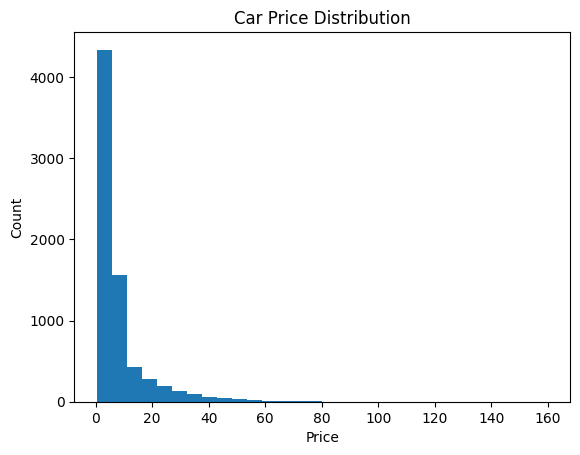

In [ ]:
plt.figure()
plt.hist(df["Price"], bins=30)
plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


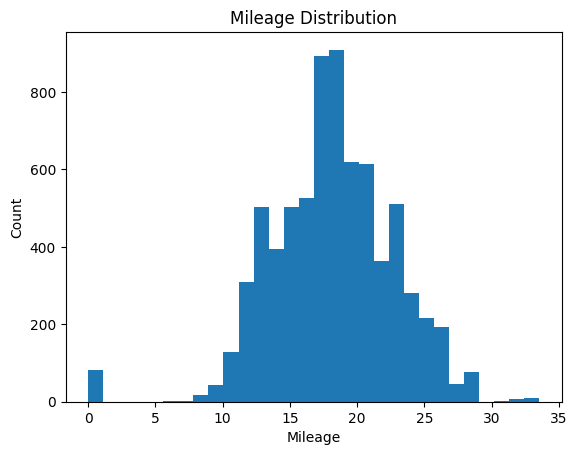

In [ ]:
plt.figure()
plt.hist(df["Mileage"], bins=30)
plt.title("Mileage Distribution")
plt.xlabel("Mileage")
plt.ylabel("Count")
plt.show()


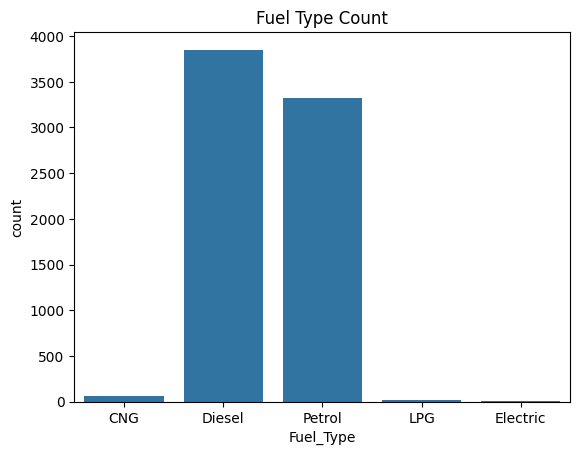

In [ ]:
plt.figure()
sns.countplot(x="Fuel_Type", data=df)
plt.title("Fuel Type Count")
plt.show()


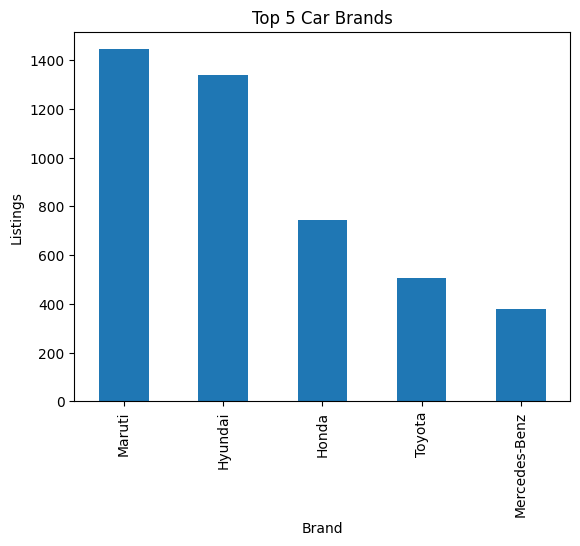

In [ ]:
top_brands = df["Brand"].value_counts().head(5)

plt.figure()
top_brands.plot(kind="bar")
plt.title("Top 5 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Listings")
plt.show()


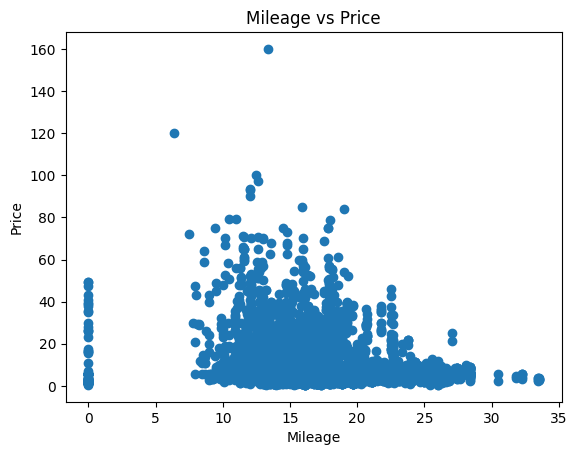

In [ ]:
plt.figure()
plt.scatter(df["Mileage"], df["Price"])
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")
plt.show()


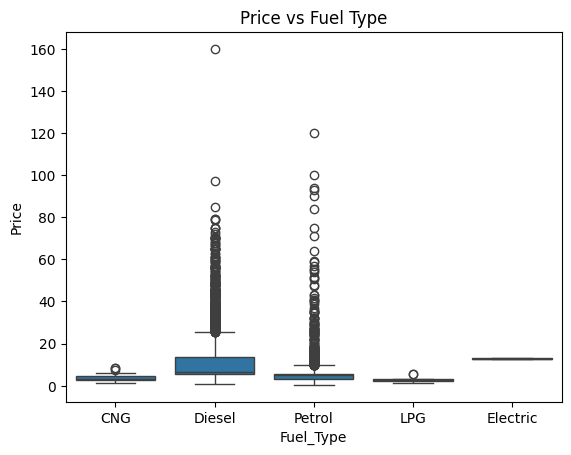

In [ ]:
plt.figure()
sns.boxplot(x="Fuel_Type", y="Price", data=df)
plt.title("Price vs Fuel Type")
plt.show()


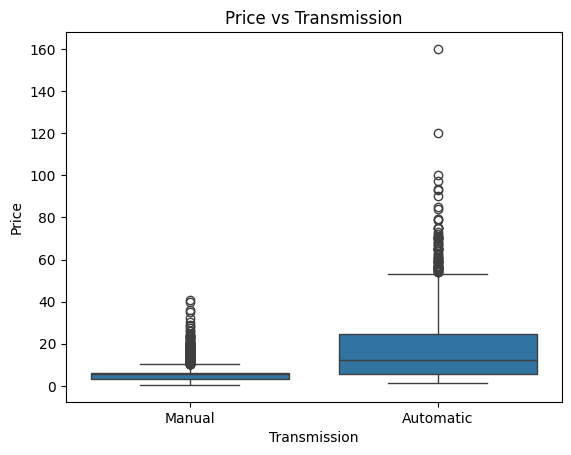

In [ ]:
plt.figure()
sns.boxplot(x="Transmission", y="Price", data=df)
plt.title("Price vs Transmission")
plt.show()


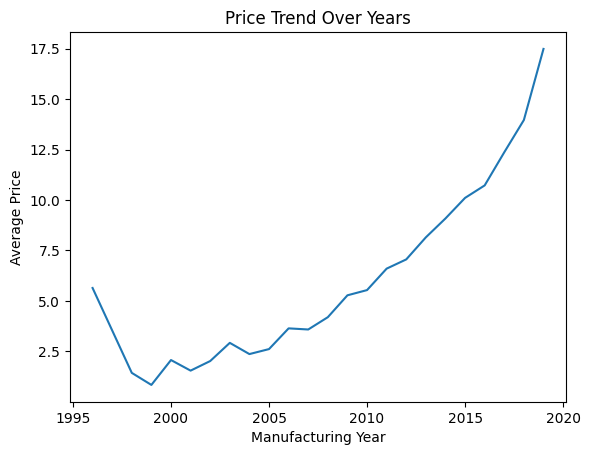

In [ ]:
year_price = df.groupby("Year")["Price"].mean()

plt.figure()
plt.plot(year_price.index, year_price.values)
plt.xlabel("Manufacturing Year")
plt.ylabel("Average Price")
plt.title("Price Trend Over Years")
plt.show()


In [ ]:
numeric_df = df.select_dtypes(include=np.number)


In [ ]:
corr = numeric_df.corr()
corr


,S.No.,Year,Kilometers_Driven,Mileage,Seats,Price
S.No.,1.000000,0.005573,-0.007697,0.019069,-0.006813,-0.106400
Year,0.005573,1.000000,-0.187859,0.322431,0.010849,0.276009
Kilometers_Driven,-0.007697,-0.187859,1.000000,-0.069111,0.089837,-0.011062
Mileage,0.019069,0.322431,-0.069111,1.000000,-0.302175,-0.278215
Seats,-0.006813,0.010849,0.089837,-0.302175,1.000000,0.047136
Price,-0.106400,0.276009,-0.011062,-0.278215,0.047136,1.000000


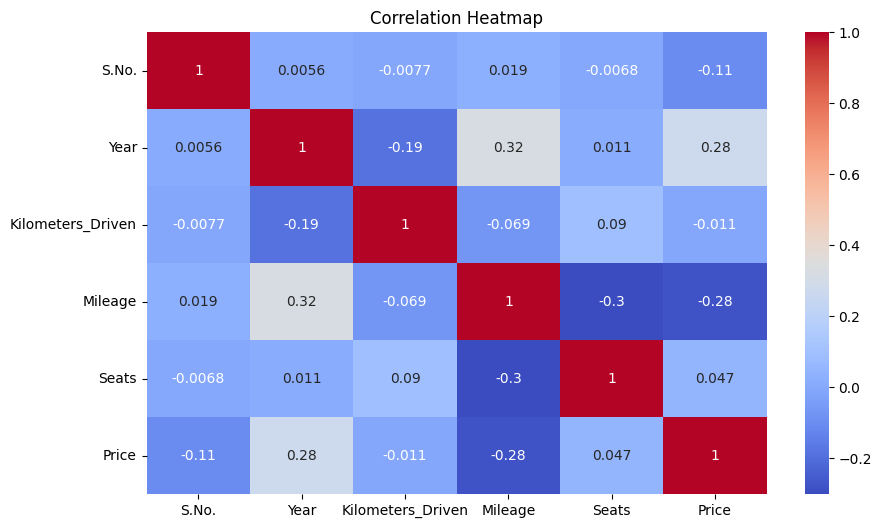

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
corr["Price"].sort_values(ascending=False)


,Price
Price,1.000000
Year,0.276009
Seats,0.047136
Kilometers_Driven,-0.011062
S.No.,-0.106400
Mileage,-0.278215


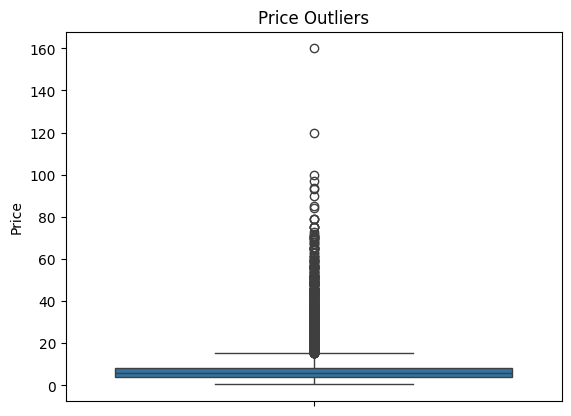

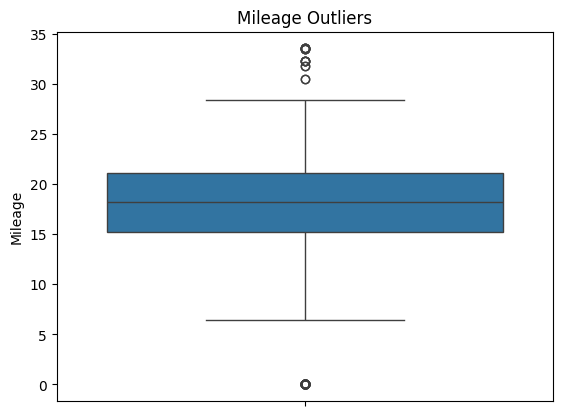

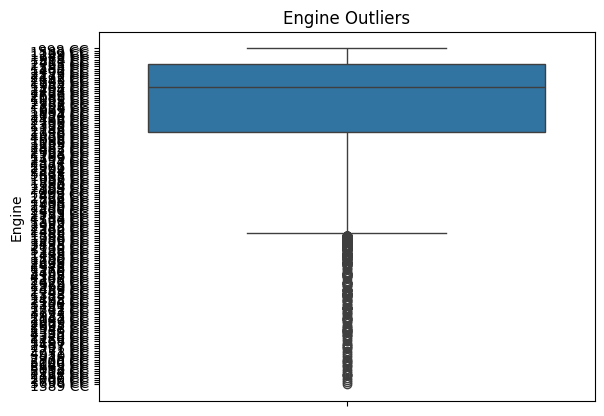

In [ ]:
plt.figure()
sns.boxplot(y=df["Price"])
plt.title("Price Outliers")
plt.show()

plt.figure()
sns.boxplot(y=df["Mileage"])
plt.title("Mileage Outliers")
plt.show()

plt.figure()
sns.boxplot(y=df["Engine"])
plt.title("Engine Outliers")
plt.show()


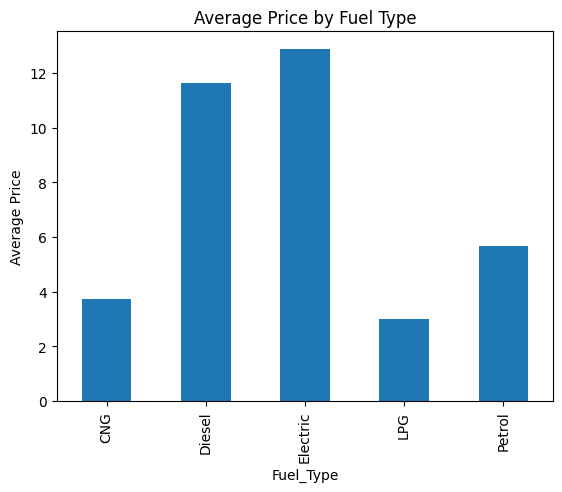

In [ ]:
fuel_price = df.groupby("Fuel_Type")["Price"].mean()

plt.figure()
fuel_price.plot(kind="bar")
plt.title("Average Price by Fuel Type")
plt.ylabel("Average Price")
plt.show()


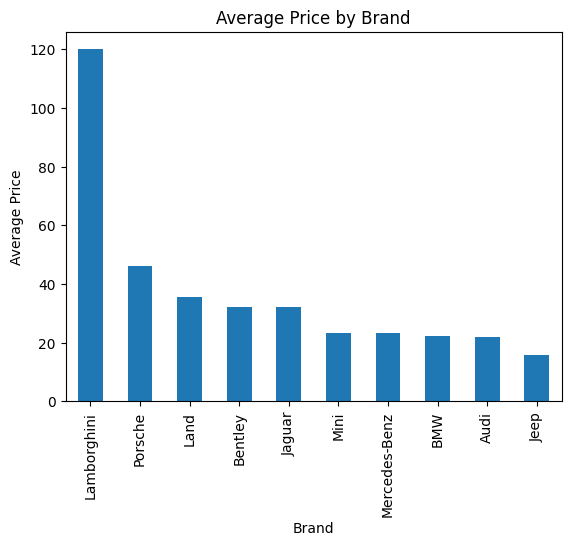

In [ ]:
brand_price = df.groupby("Brand")["Price"].mean().sort_values(ascending=False).head(10)

plt.figure()
brand_price.plot(kind="bar")
plt.title("Average Price by Brand")
plt.ylabel("Average Price")
plt.show()


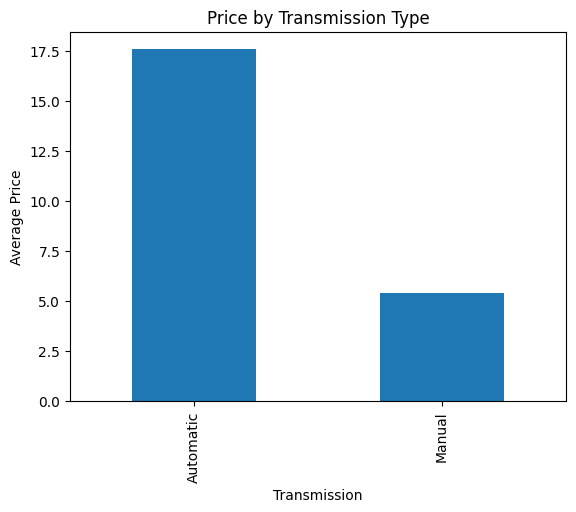

In [ ]:
trans_price = df.groupby("Transmission")["Price"].mean()

plt.figure()
trans_price.plot(kind="bar")
plt.title("Price by Transmission Type")
plt.ylabel("Average Price")
plt.show()
